<h1>Model Building - Q5</h1>

*Organzing Data*

In [6]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Model Tuning Round 1 - Data Augmentation

Round 1 emphasizes data quality and variety, the model to recognize the same object with different orientations, lighting, zoom, etc., you make the model robust and generalizable.

Since it is taking too long to train. we will go the small sample of the data  

Sample Images per Class

In [1]:
from tensorflow.keras.models import load_model

# Load your pre-trained model
model = load_model("C:\\Users\\Admin\\Downloads\\CV_Vgg\\model_final.keras")


In [11]:
import os
import shutil
import random

# === Settings ===
source_dir = r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\train'
target_dir = r'C:\Users\Admin\Downloads\CV_PROJECT_1\sample_train'
samples_per_class = 1000  # Adjust as needed

# === Create target structure ===
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if os.path.isdir(class_path):
        target_class_path = os.path.join(target_dir, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_images = random.sample(images, min(samples_per_class, len(images)))

        for img in sample_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(target_class_path, img)
            shutil.copy2(src, dst)

print(f"Copied {samples_per_class} images per class to: {target_dir}")


Copied 1000 images per class to: C:\Users\Admin\Downloads\CV_PROJECT_1\sample_train


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === Corrected Data Augmentation: No extra normalization ===
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # no augmentation, no rescaling

# === Load Image Data ===
train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\sample_train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)




Found 5000 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


Visualize Multiple Augmentations of a Single Image

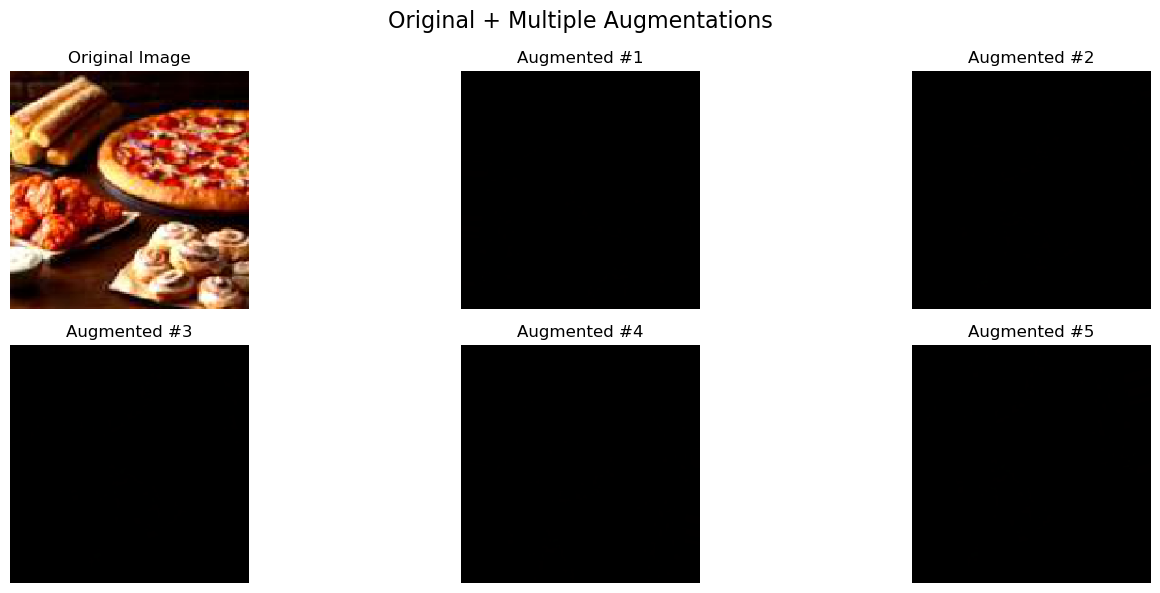

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# === Load Original Image ===
img_path = r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\train\food\__S2oSGy7vdFW2heGt5qrA_aug.jpg'  # update path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# === Augmentation ===
aug_iter = train_datagen.flow(img_batch, batch_size=1)

# === Plot original + 5 augmentations ===
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 3, 1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off')

# 5 Augmented
for i in range(5):
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 1)  # Keep pixel values in range
    plt.subplot(2, 3, i + 2)
    plt.imshow(aug_img)
    plt.title(f"Augmented #{i+1}")
    plt.axis('off')

plt.suptitle("Original + Multiple Augmentations", fontsize=16)
plt.tight_layout()
plt.show()


Removed rescale=1./255 from the train_datagen and val_datagen to avoid black images and ensure the model learns properly. The images are already normalized and rescale will do double normalization and make the image appear black

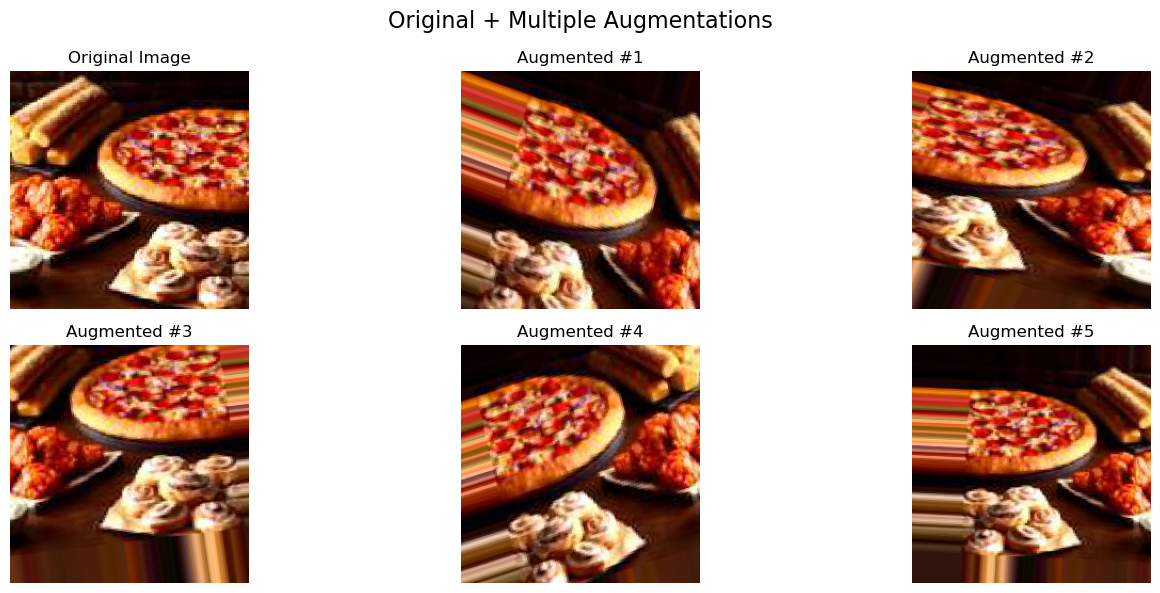

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# === Load Original Image ===
img_path = r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\train\food\__S2oSGy7vdFW2heGt5qrA_aug.jpg'  # update path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# === Augmentation ===
aug_iter = train_datagen.flow(img_batch, batch_size=1)

# === Plot original + 5 augmentations ===
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 3, 1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off')

# 5 Augmented
for i in range(5):
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 1)  # Keep pixel values in range
    plt.subplot(2, 3, i + 2)
    plt.imshow(aug_img)
    plt.title(f"Augmented #{i+1}")
    plt.axis('off')

plt.suptitle("Original + Multiple Augmentations", fontsize=16)
plt.tight_layout()
plt.show()


In [3]:
import time
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

# === Train the model ===
start_time = time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, lr_reduce]
)
end_time = time.time()
train_time = end_time - start_time
print(f"Training time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 31s/step - accuracy: 0.6489 - loss: 3.4548    

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 6011s 38s/step - accuracy: 0.6491 - loss: 3.4429 - val_accuracy: 0.7940 - val_loss: 0.6902 - learning_rate: 2.0000e-05
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3916s 25s/step - accuracy: 0.7626 - loss: 0.6620 - val_accuracy: 0.8052 - val_loss: 0.7177 - learning_rate: 2.0000e-05
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5442s 35s/step - accuracy: 0.8167 - loss: 0.5386 - val_accuracy: 0.8248 - val_loss: 0.6409 - learning_rate: 2.0000e-05
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3873s 25s/step - accuracy: 0.8225 - loss: 0.5091 - val_accuracy: 0.8285 - val_loss: 0.5987 - learning_rate: 2.0000e-05
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3302s 21s/step - accuracy: 0.8413 - loss: 0.4816 - val_accuracy: 0.8420 - val_loss: 0.5412 - learning_rate: 2.0000e-05
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3276s 21s/step - accuracy: 0.8479 - loss: 0.4262 - val_accuracy: 0.8127 - val_loss: 0.6820 - learning_rate: 2.0000e-05
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3346s 21s/step - 


Train Accuracy  from 64.9% to 87.2% shows steady improvement      
Train Loss shows significant drop from 3.44 to 0.36           


In [4]:
model.save('C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\model_tuning1.keras')

Loss & Accuracy

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator()  # no rescale

test_generator = test_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # important for correct label order
)

Found 2149 images belonging to 5 classes.


In [6]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.8516 - loss: 0.5150

Test Accuracy: 0.8497
Test Loss: 0.4702


In [7]:
import numpy as np
from sklearn.metrics import classification_report

# Predict
test_generator.reset()
Y_true_test = test_generator.classes
Y_pred_test = model.predict(test_generator, verbose=1)
Y_pred_classes_test = np.argmax(Y_pred_test, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Report
print("\n Classification Report (Test Set):")
print(classification_report(Y_true_test, Y_pred_classes_test, target_names=class_names))


68/68 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step

 Classification Report (Test Set):
              precision    recall  f1-score   support

       drink       0.89      0.86      0.87       507
        food       0.93      0.90      0.92       495
      inside       0.81      0.71      0.76       496
        menu       0.85      0.88      0.86       152
     outside       0.78      0.92      0.84       499

    accuracy                           0.85      2149
   macro avg       0.85      0.85      0.85      2149
weighted avg       0.85      0.85      0.85      2149



In [13]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


class_names = list(test_generator.class_indices.keys())
n_classes = len(class_names)
y_true_onehot = label_binarize(Y_true_test, classes=range(n_classes))


auc_score = roc_auc_score(y_true_onehot, Y_pred_test, multi_class='ovr')
print(f"Multiclass AUC Score (OvR): {auc_score:.4f}")


Multiclass AUC Score (OvR): 0.9774


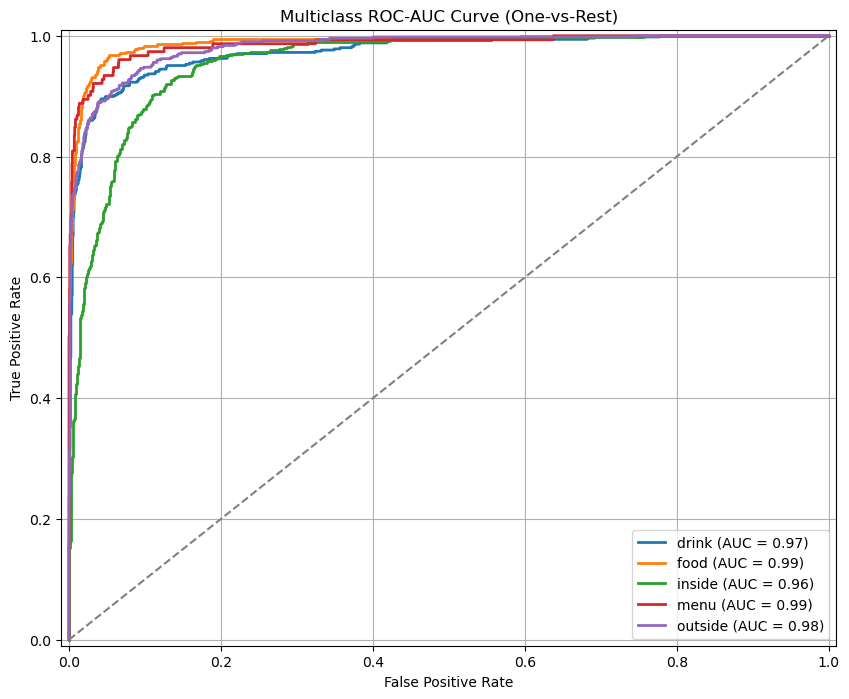

In [14]:
# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], Y_pred_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC-AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


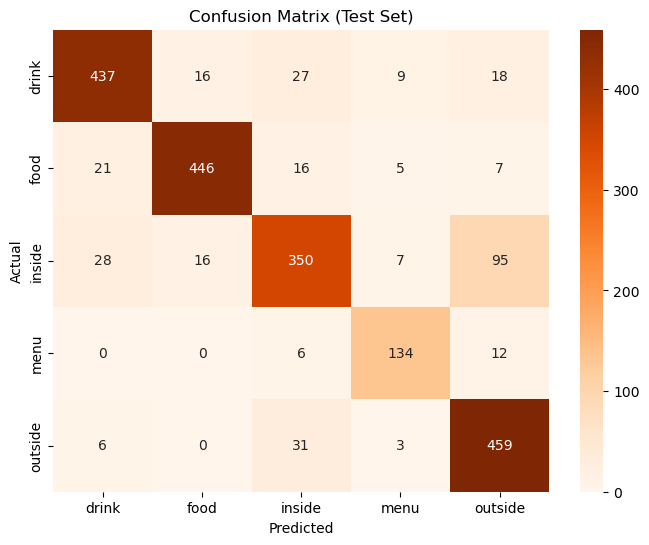

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_test = confusion_matrix(Y_true_test, Y_pred_classes_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [9]:
# Evaluation on training set

train_eval_datagen = ImageDataGenerator()  # No augmentation, no rescale
train_eval_generator = train_eval_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\sample_train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important for consistent label ordering
)


Found 5000 images belonging to 5 classes.


In [10]:
train_loss, train_acc = model.evaluate(train_eval_generator, verbose=1)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Train Loss: {train_loss:.4f}")


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.9243 - loss: 0.2170

Train Accuracy: 0.9312
Train Loss: 0.2039


In [11]:
import numpy as np
from sklearn.metrics import classification_report

# Predict on training set
train_eval_generator.reset()
Y_true_train = train_eval_generator.classes
Y_pred_train = model.predict(train_eval_generator, verbose=1)
Y_pred_classes_train = np.argmax(Y_pred_train, axis=1)

# Class label mapping
class_names = list(train_eval_generator.class_indices.keys())

# Print classification report
print("\n Classification Report (Training Set):")
print(classification_report(Y_true_train, Y_pred_classes_train, target_names=class_names))


157/157 ━━━━━━━━━━━━━━━━━━━━ 614s 4s/step

 Classification Report (Training Set):
              precision    recall  f1-score   support

       drink       0.97      0.91      0.94      1000
        food       0.94      0.98      0.96      1000
      inside       0.90      0.86      0.88      1000
        menu       0.97      0.95      0.96      1000
     outside       0.88      0.94      0.91      1000

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.93      0.93      0.93      5000



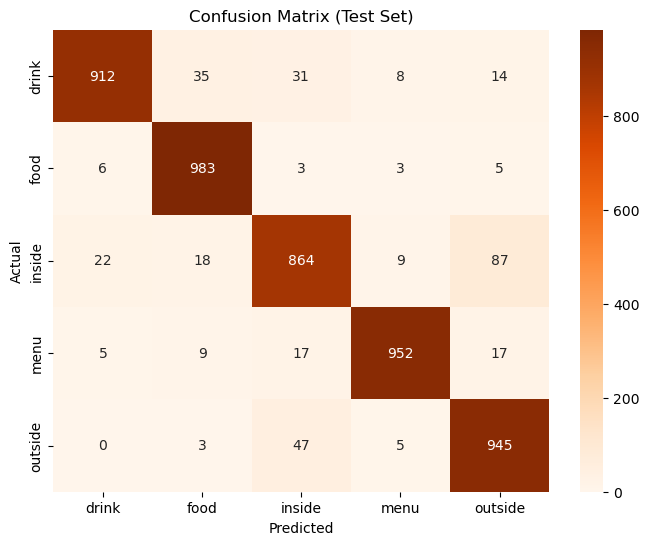

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_test = confusion_matrix(Y_true_train, Y_pred_classes_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Interpertation Comparison basemodel vs Round1 tuned Model

Tranining set Metric	Model Building	Round 1 Tuning	Change
Accuracy	89%	            93%         Improved
F1-Score Avg .90	        0.93	    Improved
inside F1	0.82	        0.88	    Clear gain
outside F1	0.90	        0.91	    Slight boost
drink F1	0.86	        0.94	     Big jump

Test set Metric	Model Building	Round 1 Tuning	Change
Accuracy     85%                85%               (same)                        
F1-Score Avg 0.85               0.85              (same)                               
`drink` F1   0.83               0.87               Improved                      
`food` F1    0.91               0.92               Slight gain                   
`inside` F1  0.76               0.76               (same)
`menu` F1    0.88               0.86               Slight drop                  
`outside` F1 0.89               0.84               Drop in precision (↑ recall) 
Round 1 tuning significantly improved generalization on training data due to regularization from augmentation.

In [ ]:
Model Tuning Round 2 Ensemble technique to handle overfitting 

In [2]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [3]:
# === Load Image Data ===
train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\sample_train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  
)

Found 5000 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


In [9]:
from tensorflow.keras.models import load_model

model1 = load_model("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\model_tuning1.keras")

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow as tf

def build_vgg16_variant(input_shape=(224, 224, 3), num_classes=5, 
                        dropout1=0.5, dropout2=0.3, 
                        dense1_units=512, dense2_units=256,
                        learning_rate=1e-4, label_smoothing=0.0):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense1_units, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout1)(x)

    x = Dense(dense2_units, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout2)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy']
    )
    return model


In [11]:
# Variant 2: Slightly smaller, faster to train
variant_2 = build_vgg16_variant(
    dropout1=0.4, dropout2=0.2,
    dense1_units=384, dense2_units=192,
    learning_rate=2e-5
)

# Variant 3: Even smaller model
variant_3 = build_vgg16_variant(
    dropout1=0.3, dropout2=0.3,
    dense1_units=256, dense2_units=128,
    learning_rate=1e-5
)


In [12]:
variant_2.fit(train_generator, validation_data=val_generator, epochs=5)
variant_2.save("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\variant_2.h5")

variant_3.fit(train_generator, validation_data=val_generator, epochs=5)
variant_3.save("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\variant_3.h5")


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4109s 26s/step - accuracy: 0.3932 - loss: 1.7026 - val_accuracy: 0.6034 - val_loss: 1.2999
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3686s 23s/step - accuracy: 0.6526 - loss: 0.9486 - val_accuracy: 0.7158 - val_loss: 0.7969
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4176s 27s/step - accuracy: 0.7276 - loss: 0.7571 - val_accuracy: 0.7614 - val_loss: 0.7081
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4500s 29s/step - accuracy: 0.7313 - loss: 0.7465 - val_accuracy: 0.7889 - val_loss: 0.6056
Epoch 5/5
  1/157 ━━━━━━━━━━━━━━━━━━━━ 1:01:22 24s/step - accuracy: 0.7812 - loss: 0.5983

KeyboardInterrupt: 

 Load both models and ensemble

In [13]:
variant_2.save("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\variant_2.h5")

In [14]:
from tensorflow.keras.models import load_model
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator()  # no rescale

test_generator = test_datagen.flow_from_directory(
    r'C:\Users\Admin\Downloads\CV_PROJECT_1\keras_data\test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # important for correct label order
)



model1 = load_model("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\model_tuning1.keras")
model2 = load_model("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\variant_2.h5")

# Predict
pred1 = model1.predict(test_generator)
pred2 = model2.predict(test_generator)

ensemble_pred = (pred1 + pred2) / 2
y_pred_classes = np.argmax(ensemble_pred, axis=1)


Found 2149 images belonging to 5 classes.


68/68 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 298s 4s/step


              precision    recall  f1-score   support

           0       0.94      0.78      0.85       507
           1       0.94      0.74      0.83       495
           2       0.85      0.32      0.47       496
           3       0.85      0.88      0.86       152
           4       0.49      0.98      0.66       499

    accuracy                           0.72      2149
   macro avg       0.81      0.74      0.73      2149
weighted avg       0.81      0.72      0.71      2149



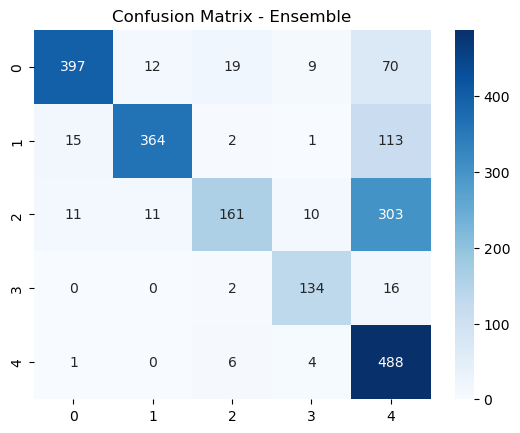

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = test_generator.classes
print(classification_report(y_true, y_pred_classes))

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - Ensemble")
plt.show()


In [ ]:
Conclusion
Round 1 gave better overall accuracy and F1-score, especially for hard-to-classify classes like inside.

Round 2 (ensemble) showed imbalanced behavior: Some classes improved, but others worsened due to bias in model predictions.

While ensembling helped with certain features, fine-grained class confusion remained, especially without deeper architectural changes or additional contextual modeling.

